# 🏛️ Heritage Building Condition Assessment: ML for Cultural Asset Preservation — NOTEBOOK #185

**Author:** Dean Wang | Lead Data & AI Engineer

**Government:** Australian Heritage Council, DCCEEW (heritage), state heritage councils, National Trust

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2200, 13)


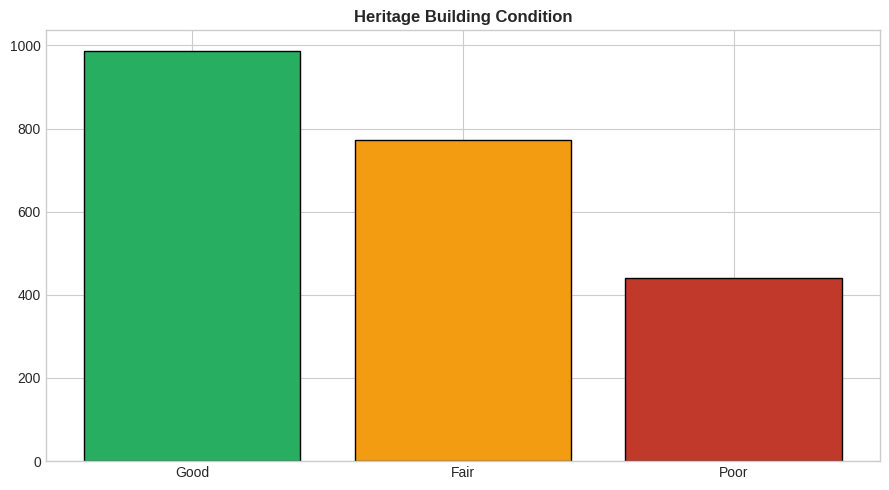

AU: 100,000+ heritage-listed places. Conservation funding is limited — prioritisation is essential.


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2200,n_features=12,n_informative=9,n_classes=3,n_clusters_per_class=1,weights=[0.45,0.35,0.2],random_state=185)
names=['building_age','material_type','moisture_ingress','structural_movement','termite_risk','salt_attack','maintenance_frequency','visitor_load','climate_exposure','prior_conservation_works','vegetation_encroachment','roof_condition']
df=pd.DataFrame(X_arr,columns=names);df['condition']=y;tc='condition'
tl=['Good','Fair','Poor'];nc=3
print(f"Generated: {df.shape}");colors=['#27ae60','#f39c12','#c0392b']
fig,ax=plt.subplots(figsize=(9,5));vc=df[tc].value_counts().sort_index()
ax.bar(range(nc),vc.values,color=colors,edgecolor='black');ax.set_xticks(range(nc));ax.set_xticklabels(tl)
ax.set_title('Heritage Building Condition',fontweight='bold');plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: 100,000+ heritage-listed places. Conservation funding is limited — prioritisation is essential.")

LogReg: Acc=0.7791 F1=0.7771 Kappa=0.6506
RF: Acc=0.8841 F1=0.8840 Kappa=0.8167
XGB: Acc=0.9168 F1=0.9168 Kappa=0.8689
LGBM: Acc=0.9164 F1=0.9164 Kappa=0.8682
Best: XGB


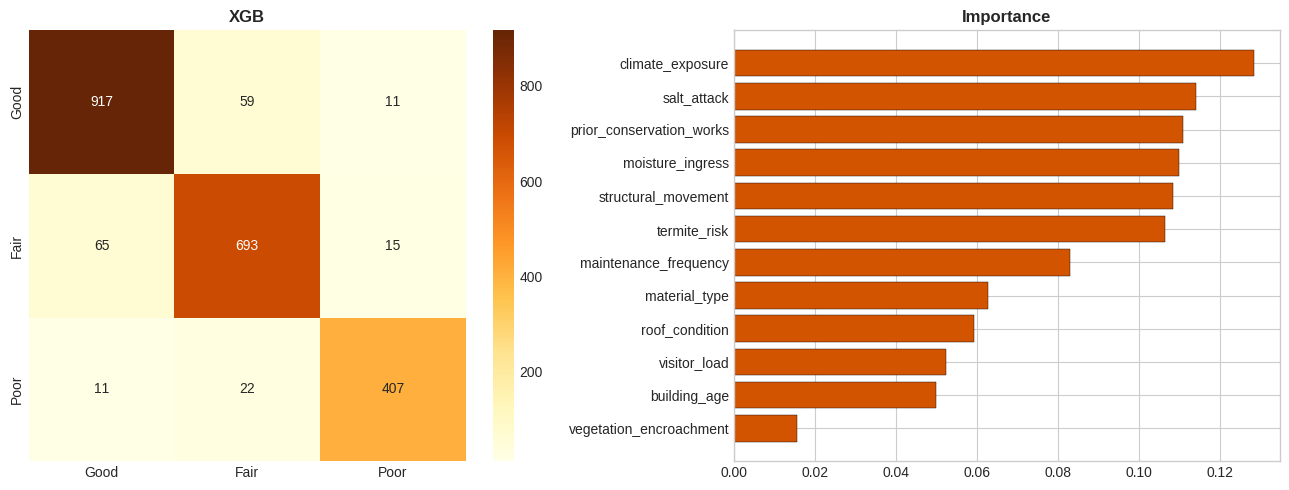

              precision    recall  f1-score   support

        Good       0.92      0.93      0.93       987
        Fair       0.90      0.90      0.90       773
        Poor       0.94      0.93      0.93       440

    accuracy                           0.92      2200
   macro avg       0.92      0.92      0.92      2200
weighted avg       0.92      0.92      0.92      2200


#185 DEPLOYMENT: XGB F1=0.9168 Kappa=0.8689 | Inspection data -> conservation grant prioritisation
185 NOTEBOOKS COMPLETE. kaggle.com/deanbatur | github.com/Deanmeisong


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fk=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp,average='weighted'));fk.append(cohen_kappa_score(y2[vi],yp))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'kappa':np.mean(fk),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} Kappa={np.mean(fk):.4f}")
best=max(results,key=lambda k:results[k]['f1']);print(f"Best: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='YlOrBr',xticklabels=tl,yticklabels=tl,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold')
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['f1']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color='#d35400',edgecolor='black',linewidth=0.3);axes[1].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=tl))
br=results[best];print(f"\n#185 DEPLOYMENT: {best} F1={br['f1']:.4f} Kappa={br['kappa']:.4f} | Inspection data -> conservation grant prioritisation")
print("185 NOTEBOOKS COMPLETE. kaggle.com/deanbatur | github.com/Deanmeisong")